In [82]:
from typing import TypedDict , Annotated , Optional
from langgraph.graph import StateGraph , END , add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.memory import MemorySaver
from uuid import uuid4
import json

In [83]:
load_dotenv()

True

In [84]:
import os

api_key = os.getenv("GEMINI_API_KEY")

In [85]:
model = ChatGoogleGenerativeAI(
   model="models/gemini-2.5-flash",
    google_api_key=api_key
)

In [86]:
# response=model.invoke("give me a joke about cats")

In [87]:
# response

In [88]:
search_tool =TavilySearchResults(max_result=2)

In [89]:
# response=search_tool.invoke("what is the weather in delhi")

In [90]:
# response

In [91]:
tools= [search_tool]
memory = MemorySaver()
llm_with_tools =model.bind_tools(tools=tools)

In [92]:
from langchain_core.messages import AIMessage , HumanMessage , ToolMessage


In [93]:
class AgentState(TypedDict):
    messages: Annotated[list,add_messages]

In [100]:
async def model(state: AgentState):
    result = await llm_with_tools.ainvoke(state["messages"])
    return {
        "messages": [result]
    }

def tools_router(state: AgentState):
    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tool_node"

    return END

async def tools_node(state: AgentState):
    tool_calls = state["messages"][-1].tool_calls
    tool_messages = []

    for tool_call in tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]

        if tool_name == "tavily_search_results_json":
            search_result = await search_tool.ainvoke(tool_args)

            tool_message = ToolMessage(
                content=str(search_result),
                tool_call_id=tool_id,
                name=tool_name
            )

            tool_messages.append(tool_message)

    return {"messages": tool_messages}

In [101]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("model", model)
graph_builder.add_node("tool_node", tools_node)
graph_builder.set_entry_point("model")

graph_builder.add_conditional_edges("model", tools_router)
graph_builder.add_edge("tool_node", "model")

graph = graph_builder.compile(checkpointer=memory)

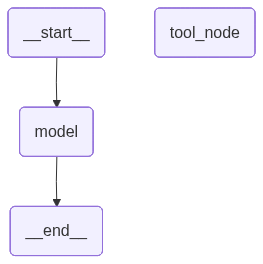

In [102]:
from IPython.display import Image , display

display(Image(graph.get_graph().draw_mermaid_png()))